# Freight Rate Prediction — Spotter ML Assessment


**Daniel Peralta** — Machine Learning Engineer Assessment, Spotter


In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pd.set_option('display.width', 200)

## 1. Data Exploration

In [42]:
df = pd.read_csv('train-test.csv')
df.columns

Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate'], dtype='object')

### 1.1 Valores nulos

In [43]:
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

weight has 300 NaN values, and market_index has 374. Both are left as NaN rather than imputed — the chosen model (HistGradientBoostingRegressor) handles missing values natively, so there's no need to fill them with medians, which could introduce bias.

### 1.2 Descriptive statistics (before clenaing `weight`)

In [44]:
cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
df[cols].describe()

,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,3439.800000,47500.000000,1.467780,3.610350,25533.000000


The minimun `weight` value is negative (-47,500 lb), That is not possible

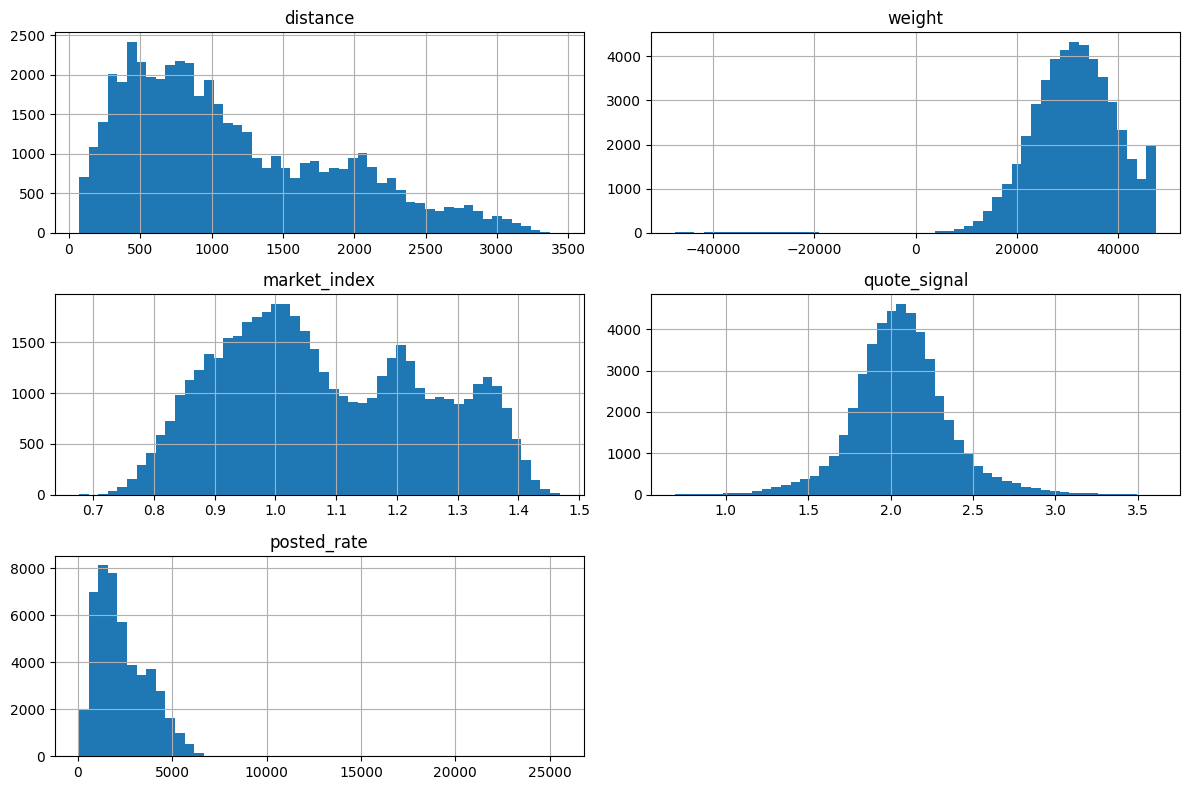

In [45]:
df[cols].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

### 1.3 Sign bug in `weight` — 292 rows (~0.6%) with negative weight


Magnitude of negative values are the same than positive values (median, standard deviation) - that it means is a sign bud, not a corrupted data. To fix it, the use of absolute value reverse the sign with no necessity to delete rows.

In [46]:
df['weight'] = df['weight'].abs()
df[cols].describe()

,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,1135.856654,31417.249245,1.083387,2.062468,2373.980682
std,728.564416,7996.515399,0.168091,0.291391,1486.493245
min,70.000000,5000.000000,0.676390,0.692280,57.220000
25%,550.400000,25922.000000,0.949670,1.891030,1251.555000
50%,953.300000,31496.000000,1.055800,2.055750,2030.760000
75%,1645.525000,37063.250000,1.219590,2.221685,3330.750000
max,3439.800000,47500.000000,1.467780,3.610350,25533.000000


### 1.4 Correlations

In [47]:
df[['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']].corr()

,distance,weight,market_index,quote_signal,posted_rate
distance,1.000000,0.001862,-0.002181,-0.057244,0.908519
weight,0.001862,1.000000,0.002670,0.006107,0.041343
market_index,-0.002181,0.002670,1.000000,-0.067827,0.034165
quote_signal,-0.057244,0.006107,-0.067827,1.000000,-0.039858
posted_rate,0.908519,0.041343,0.034165,-0.039858,1.000000



`market_index` and `quote_signal` hardly correlate with `posted_rate` (0.03 y -0.04). In the model they still there — allowing us to consider them important rather than dismissing them without analysis.

In [48]:
np.corrcoef(np.log(df['distance']), np.log(df['posted_rate']))

array([[1.        , 0.96740987],
       [0.96740987, 1.        ]])


In the space log-log the correlate with `distance` improves 0.905 to 0.97 - the relation rate/distance is not lineal. For taht reason it modelates `log(posted_rate)` and `log(distance)` is use like feature.

### 1.5 Effect of equipment type

In [49]:
df.groupby('equipment')['posted_rate'].mean()

equipment
Dry Van    2271.548686
Flatbed    2445.087223
Reefer     2553.636939
Name: posted_rate, dtype: float64

In [50]:
df['rate_per_mile'] = df['posted_rate'] / df['distance']
df.groupby('equipment')['rate_per_mile'].mean()

equipment
Dry Van    2.115401
Flatbed    2.294729
Reefer     2.383376
Name: rate_per_mile, dtype: float64

Reefer > Flatbed > Dry Van in rate per mile — agrees with the economy of transport (Specialized/refrigerated equipment costs more).

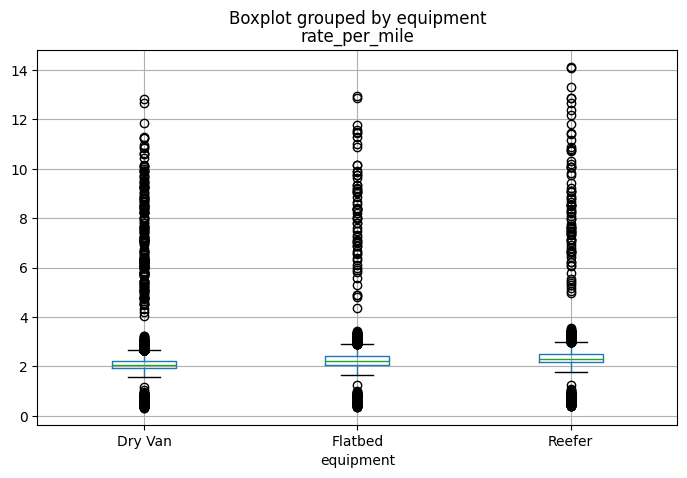

In [51]:
df.boxplot(column='rate_per_mile', by='equipment', figsize=(8,5))
plt.show()

In [52]:
outliers = df[df['rate_per_mile'] > 6]
print('Distance for the outliers:')
print(outliers['distance'].describe())
print()
print('Distance for all the trips:')
print(df['distance'].describe())

Distance for the outliers:
count     270.000000
mean      963.761852
std       649.207026
min        70.000000
25%       439.925000
50%       832.150000
75%      1347.400000
max      2979.100000
Name: distance, dtype: float64

Distance for all the trips:
count    48000.000000
mean      1135.856654
std        728.564416
min         70.000000
25%        550.400000
50%        953.300000
75%       1645.525000
max       3439.800000
Name: distance, dtype: float64




The outliers rate/mile very high tend to be shorter routes (fixed per load + variable per mile makes short miles have a higher rate/mile) — consistent with the power law, not a mistake.

### 1.6 Is there monthly seasonality? — and why it can't be blindly trusted

In [53]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df.groupby('month')['rate_per_mile'].mean()

month
1     2.100221
2     2.122885
3     2.206132
4     2.210309
5     2.260106
6     2.332484
7     2.255952
8     2.188584
9     2.229725
10    2.239763
Name: rate_per_mile, dtype: float64

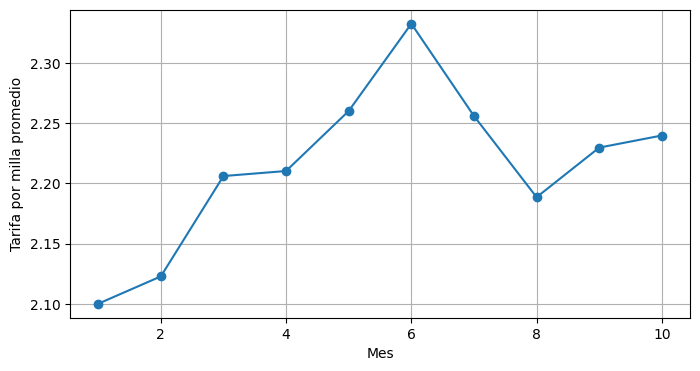

In [54]:
df.groupby('month')['rate_per_mile'].mean().plot(marker='o', figsize=(8,4))
plt.xlabel('Mes')
plt.ylabel('Tarifa por milla promedio')
plt.grid(True)
plt.show()


There is a visible pattern (It increase since January to mid-June). The real question is if the pattern **still increase with the time** which is exactly what needs to be predicted for november/december. A small test: adjust trend only for January-August to see if the model can predict well september-october.

In [55]:
monthly = df.groupby('month')['rate_per_mile'].mean()

train_months = monthly.loc[1:8]
coef = np.polyfit(train_months.index, train_months.values, 1)

prediccion = np.polyval(coef, [9, 10])
print('Real prediction for sep/oct with Jan-Aug trend:', prediccion)
print('Real value:', monthly.loc[9], monthly.loc[10])

Real prediction for sep/oct with Jan-Aug trend: [2.30133774 2.32172742]
Real value: 2.2297249726276376 2.2397625947405086


In [56]:
prediccion_sep_oct = np.polyval(coef, [9, 10])
real_sep_oct = monthly.loc[[9, 10]].values
error_pct = (prediccion_sep_oct - real_sep_oct) / real_sep_oct * 100

print('Prediction:', prediccion_sep_oct)
print('Real:        ', real_sep_oct)
print('Error %:', error_pct)

Prediction: [2.30133774 2.32172742]
Real:         [2.22972497 2.23976259]
Error %: [3.21173097 3.65953171]


The linear trend is off by about 3.2-3.7% when it predicts only 1-2 months ahead. This is a real signal, but a weak one — not something to force with a strong correction (we check this again later, in the model comparison).

In [57]:
coef_completo = np.polyfit(monthly.index, monthly.values, 1)
prediccion_nov_dic = np.polyval(coef_completo, [11, 12])
print('Prediction nov/dic:', prediccion_nov_dic)

Prediction nov/dic: [2.28546024 2.29834099]


## 2. Preparación de features

In [58]:
df_encoded = pd.get_dummies(df, columns=['equipment'], drop_first=True)
df_encoded['log_distance'] = np.log(df_encoded['distance'])
df_encoded['log_rate'] = np.log(df_encoded['posted_rate'])
df_encoded['date'] = pd.to_datetime(df_encoded['date'])

features = ['log_distance'] + [c for c in df_encoded.columns if c.startswith('equipment_')]
df_encoded.filter(like='equipment').head()

,equipment_Flatbed,equipment_Reefer
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True


### Temporary slit (non-random)

The real task is to predict Nov/Dec- months the model never saw before, A random split would leave free to the model to train and validate with the same month samples, Which hidden the mistakes to extrapolate. Instead: It trainieren with January-August, and validate with September and October.

In [59]:
train = df_encoded[df_encoded['date'] < '2025-09-01']
test = df_encoded[df_encoded['date'] >= '2025-09-01']

print('Train:', train.shape, ' Test:', test.shape)

Train: (38477, 19)  Test: (9523, 19)


## 3. Base Model-Linear Regression

In [60]:
from sklearn.linear_model import LinearRegression

X_train = train[features]
y_train = train['log_rate']
X_test = test[features]
y_test = test['log_rate']

model = LinearRegression()
model.fit(X_train, y_train)

for name, coef in zip(features, model.coef_):
    print(f'{name}: {coef:.4f}')
print('intercept:', model.intercept_)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
for name, coef in zip(features, model.coef_):
    if name.startswith('equipment_'):
        pct = (np.exp(coef) - 1) * 100
        print(f'{name}: cuesta {pct:.1f}% más que Dry Van')

equipment_Flatbed: cuesta 8.3% más que Dry Van
equipment_Reefer: cuesta 12.5% más que Dry Van


In [ ]:
y_pred = np.exp(model.predict(X_test))
y_actual = np.exp(y_test)

mae = np.mean(np.abs(y_actual - y_pred))
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
print(f'MAE: ${mae:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE: $134.70
MAPE: 6.03%


**Baseline: MAPE 6.03%.** Is the baseline to improve the next models.

## 4. Comparison of models — HistGradientBoostingRegressor

### 4.1 Without date

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

print((df_encoded['weight'] < 0).sum())  # confirma que el fix de weight sigue aplicado, debe dar 0

features_hgb = features + ['weight', 'market_index', 'quote_signal']

X_train_hgb = train[features_hgb]
X_test_hgb = test[features_hgb]

hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train_hgb, y_train)

y_pred_hgb = np.exp(hgb.predict(X_test_hgb))
mae_hgb = np.mean(np.abs(y_actual - y_pred_hgb))
mape_hgb = np.mean(np.abs((y_actual - y_pred_hgb) / y_actual)) * 100
print(f'MAE: ${mae_hgb:.2f}')
print(f'MAPE: {mape_hgb:.2f}%')

0
MAE: $141.00
MAPE: 5.98%


MAPE 5.98% — better than the baseline, but with no date variable. This model can't tell one day from another. The December chart, shown in the next section, comes out as a flat line (one repeated value) — not because the model is being careful, but because it has nothing that changes with the date.

### 4.2 With a date, as normal characteristics of the tree

In [ ]:
df_encoded['day_of_year'] = df_encoded['date'].dt.dayofyear
df_encoded['doy_sin'] = np.sin(2 * np.pi * df_encoded['day_of_year'] / 365.25)
df_encoded['doy_cos'] = np.cos(2 * np.pi * df_encoded['day_of_year'] / 365.25)
df_encoded['days_since_start'] = (df_encoded['date'] - df_encoded['date'].min()).dt.days

train = df_encoded[df_encoded['date'] < '2025-09-01']
test = df_encoded[df_encoded['date'] >= '2025-09-01']

features_v2 = features_hgb + ['doy_sin', 'doy_cos', 'days_since_start']

X_train_v2 = train[features_v2]
X_test_v2 = test[features_v2]

hgb2 = HistGradientBoostingRegressor(random_state=42)
hgb2.fit(X_train_v2, y_train)

y_pred_v2 = np.exp(hgb2.predict(X_test_v2))
mae_v2 = np.mean(np.abs(y_actual - y_pred_v2))
mape_v2 = np.mean(np.abs((y_actual - y_pred_v2) / y_actual)) * 100
print(f'MAE: ${mae_v2:.2f}')
print(f'MAPE: {mape_v2:.2f}%')

MAE: $131.63
MAPE: 5.69%



MAPE 5.69% — the best so far. `doy_sin`/`doy_cos` stay between -1 and 1 for any date (they don't jump to extreme values when we predict into November/December). The boosting tree decides, using its own regularization, how much to trust them. The jump from 5.98% to 5.69%, just from adding these 3 columns, is much bigger than what we later gained from tuning hyperparameters — the date matters more than fine-tuning.

Index(['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate'], dtype='object')


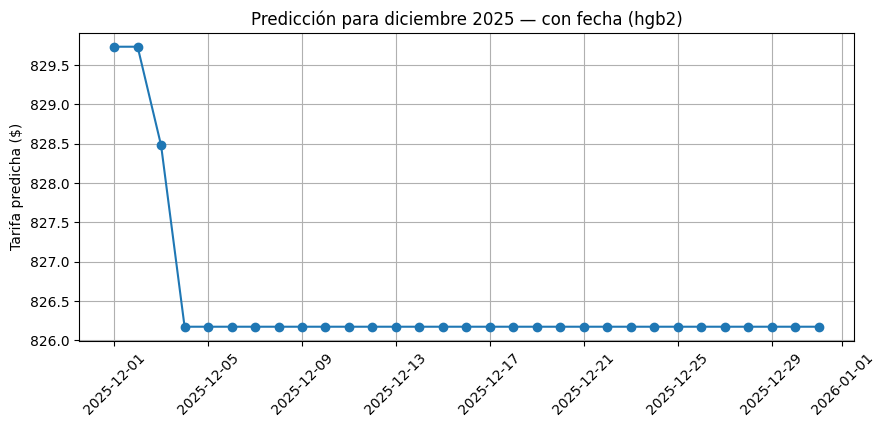

In [ ]:
dec = pd.read_csv('december-chart-inputs.csv')
print(dec.columns)

city_coords = pd.concat([
    df[['pickup','pickup_lat','pickup_lon']].rename(columns={'pickup':'city','pickup_lat':'lat','pickup_lon':'lon'}),
    df[['delivery','delivery_lat','delivery_lon']].rename(columns={'delivery':'city','delivery_lat':'lat','delivery_lon':'lon'})
]).drop_duplicates('city').set_index('city')

dec['date'] = pd.to_datetime(dec['date'])
dec['log_distance'] = np.log(dec['distance'])
dec['equipment_Flatbed'] = 0
dec['equipment_Reefer'] = 0   
dec['market_index'] = df['market_index'].median()   
dec['quote_signal'] = df['quote_signal'].median()
dec['day_of_year'] = dec['date'].dt.dayofyear
dec['doy_sin'] = np.sin(2*np.pi*dec['day_of_year']/365.25)
dec['doy_cos'] = np.cos(2*np.pi*dec['day_of_year']/365.25)
dec['days_since_start'] = (dec['date'] - df_encoded['date'].min()).dt.days

dec_pred = np.exp(hgb2.predict(dec[features_v2]))

plt.figure(figsize=(10,4))
plt.plot(dec['date'], dec_pred, marker='o')
plt.title('Predicción para diciembre 2025 — con fecha (hgb2)')
plt.ylabel('Tarifa predicha ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 4.3 Tried and discarded approaches (documented for transparency)

**a) Date with no `days_since_start`** — Same MAPE aprox- but is not the final version.

MAPE: 5.91%


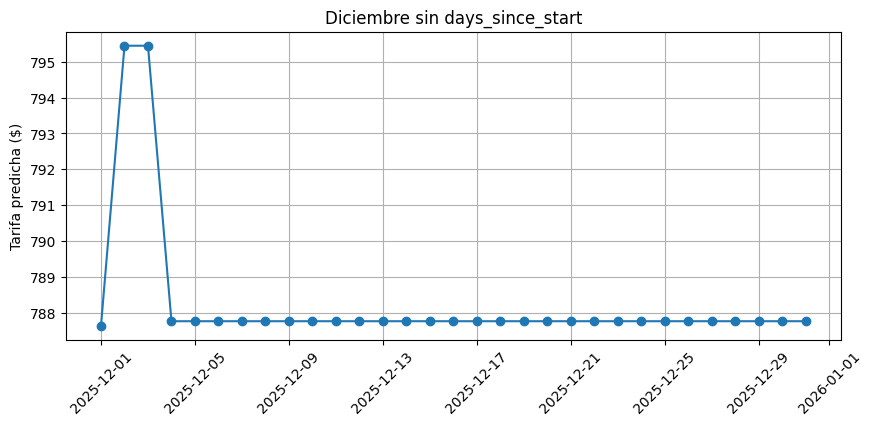

In [ ]:
features_v3 = features_hgb + ['doy_sin', 'doy_cos']

X_train_v3 = train[features_v3]
X_test_v3 = test[features_v3]

hgb3 = HistGradientBoostingRegressor(random_state=42)
hgb3.fit(X_train_v3, y_train)

y_pred_v3 = np.exp(hgb3.predict(X_test_v3))
mape_v3 = np.mean(np.abs((y_actual - y_pred_v3) / y_actual)) * 100
print(f'MAPE: {mape_v3:.2f}%')

dec_pred_v3 = np.exp(hgb3.predict(dec[features_v3]))
plt.figure(figsize=(10,4))
plt.plot(dec['date'], dec_pred_v3, marker='o')
plt.title('Diciembre sin days_since_start')
plt.ylabel('Tarifa predicha ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**b) No date variable at all (the `hgb` model from section 4.1)**— December comes out completely flat: one repeated value for all 31 days, because the other columns in the December file are the same for every row, and this model has no variable that changes with the date.


[836.48637001 836.48637001 836.48637001 836.48637001 836.48637001] [836.48637001 836.48637001 836.48637001 836.48637001 836.48637001]


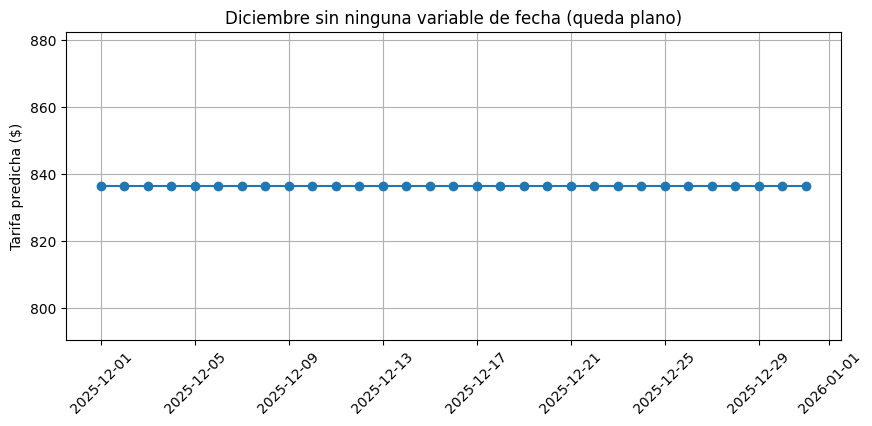

In [ ]:
dec_pred_nodate = np.exp(hgb.predict(dec[features_hgb]))
print(dec_pred_nodate[:5], dec_pred_nodate[-5:])

plt.figure(figsize=(10,4))
plt.plot(dec['date'], dec_pred_nodate, marker='o')
plt.title('Diciembre sin ninguna variable de fecha (queda plano)')
plt.ylabel('Tarifa predicha ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**c) Búsqueda de hiperparámetros** (sobre el modelo sin fecha, `features_hgb`) — el mejor combo encontrado es `max_depth=8, learning_rate=0.03, max_iter=400, l2_regularization=0.1`. Se reutiliza este mismo combo para el modelo con fecha en la sección 4.2/final — la mejora por tuneo es pequeña (5.69% → 5.68%) comparada con la mejora por incluir la fecha (5.98% → 5.69%).

In [ ]:
from itertools import product

param_grid = {
    'max_depth': [4, 6, 8, None],
    'learning_rate': [0.03, 0.06, 0.1],
    'max_iter': [200, 400],
    'l2_regularization': [0.0, 0.1, 1.0],
}

results = []
for max_depth, lr, max_iter, l2 in product(
    param_grid['max_depth'], param_grid['learning_rate'],
    param_grid['max_iter'], param_grid['l2_regularization']
):
    m = HistGradientBoostingRegressor(
        max_depth=max_depth, learning_rate=lr,
        max_iter=max_iter, l2_regularization=l2, random_state=42
    )
    m.fit(X_train_v2, y_train)  
    pred = np.exp(m.predict(X_test_v2))
    mape = np.mean(np.abs((y_actual - pred) / y_actual)) * 100
    results.append((max_depth, lr, max_iter, l2, mape))

results_df = pd.DataFrame(results, columns=['max_depth','learning_rate','max_iter','l2_reg','mape'])
results_df.sort_values('mape').head(10)

,max_depth,learning_rate,max_iter,l2_reg,mape
18,6.0,0.03,200,0.0,5.594147
21,6.0,0.03,400,0.0,5.594147
54,NaN,0.03,200,0.0,5.624554
37,8.0,0.03,200,0.1,5.632365
57,NaN,0.03,400,0.0,5.632574
6,4.0,0.06,200,0.0,5.634378
9,4.0,0.06,400,0.0,5.634378
65,NaN,0.06,400,1.0,5.634582
62,NaN,0.06,200,1.0,5.634582
36,8.0,0.03,200,0.0,5.635498


**d) Adding pickup/delivery city as dummy variables** — doesn't help (5.95% and 5.93%, worse than the model with date). With hundreds of cities and ~48k rows, each city has only a few observations, so the model spreads itself thin without gaining real accuracy. Dropped.

In [ ]:
df_lanes = pd.get_dummies(df_encoded, columns=['pickup', 'delivery'], prefix=['pu', 'de'])

lane_cols = [c for c in df_lanes.columns if c.startswith('pu_') or c.startswith('de_')]
features_lanes = features_hgb + lane_cols

train_lanes = df_lanes[df_lanes['date'] < '2025-09-01']
test_lanes = df_lanes[df_lanes['date'] >= '2025-09-01']

X_train_lanes = train_lanes[features_lanes]
X_test_lanes = test_lanes[features_lanes]

hgb_lanes = HistGradientBoostingRegressor(
    max_depth=8, learning_rate=0.03, max_iter=400, l2_regularization=0.1, random_state=42
)
hgb_lanes.fit(X_train_lanes, y_train)

pred_lanes = np.exp(hgb_lanes.predict(X_test_lanes))
mape_lanes = np.mean(np.abs((y_actual - pred_lanes) / y_actual)) * 100
print(f'MAPE with cities: {mape_lanes:.2f}%')

MAPE con ciudades: 5.95%


In [ ]:
df_pickup_only = pd.get_dummies(df_encoded, columns=['pickup'], prefix='pu')
pickup_cols = [c for c in df_pickup_only.columns if c.startswith('pu_')]
features_pu = features_hgb + pickup_cols

train_pu = df_pickup_only[df_pickup_only['date'] < '2025-09-01']
test_pu = df_pickup_only[df_pickup_only['date'] >= '2025-09-01']

hgb_pu = HistGradientBoostingRegressor(
    max_depth=8, learning_rate=0.03, max_iter=400, l2_regularization=0.1, random_state=42
)
hgb_pu.fit(train_pu[features_pu], y_train)
pred_pu = np.exp(hgb_pu.predict(test_pu[features_pu]))
mape_pu = np.mean(np.abs((y_actual - pred_pu) / y_actual)) * 100
print(f'MAPE pickup only: {mape_pu:.2f}%')

MAPE solo con pickup: 5.93%


5. Final model

**Features:** `features_hgb` (`log_distance`, `equipment_*`, `weight`, `market_index`, `quote_signal`) + `doy_sin`, `doy_cos`, `days_since_start`..
**Hyperparameters:** the ones from the grid search done on this same feature set (section 4.3c) — `max_depth=6, learning_rate=0.03, max_iter=400, l2_regularization=0.0`.
**Training:** on 100% of the 48,000 labeled rows (no need to hold out anymore — the honest MAPE for this exact configuration was already measured above:**~5.59%**, see section 5.1).

In [ ]:
features_final = features_hgb + ['doy_sin', 'doy_cos', 'days_since_start']

final_model = HistGradientBoostingRegressor(
    max_depth=6, learning_rate=0.03, max_iter=200, l2_regularization=0.0, random_state=42
)
final_model.fit(df_encoded[features_final], df_encoded['log_rate'])

HistGradientBoostingRegressor(learning_rate=0.03, max_depth=6, max_iter=200,
                              random_state=42)

### 5.1 Honest MAPE for this exact configuration (Sep-Oct holdout, not used to train `final_model`)

In [ ]:
holdout_check = HistGradientBoostingRegressor(
    max_depth=6, learning_rate=0.03, max_iter=400, l2_regularization=0.0, random_state=42
)
holdout_check.fit(train[features_final], y_train)
pred_check = np.exp(holdout_check.predict(test[features_final]))
mape_final = np.mean(np.abs((y_actual - pred_check) / y_actual)) * 100
print(f'MAPE (features_final, hiperparametros tuneados sobre features_v2): {mape_final:.2f}%')

MAPE (features_final, hiperparametros tuneados sobre features_v2): 5.59%


## 6. Output Archives

### 6.1 `validation_predictions.csv`

In [ ]:
val = pd.read_csv('validation.csv')
val_encoded = pd.get_dummies(val, columns=['equipment'], drop_first=True)
for col in ['equipment_Flatbed', 'equipment_Reefer']:
    if col not in val_encoded.columns:
        val_encoded[col] = 0
val_encoded['log_distance'] = np.log(val_encoded['distance'])
val_encoded['weight'] = val_encoded['weight'].abs()   # mismo fix del signo, por si acaso
val_encoded['date'] = pd.to_datetime(val_encoded['date'])
val_encoded['day_of_year'] = val_encoded['date'].dt.dayofyear
val_encoded['doy_sin'] = np.sin(2*np.pi*val_encoded['day_of_year']/365.25)
val_encoded['doy_cos'] = np.cos(2*np.pi*val_encoded['day_of_year']/365.25)
val_encoded['days_since_start'] = (val_encoded['date'] - df_encoded['date'].min()).dt.days

val_pred = np.exp(final_model.predict(val_encoded[features_final]))

template = pd.read_csv('validation-predictions-template.csv')
assert list(template['load_id']) == list(val['load_id'])
template['predicted_rate'] = np.round(val_pred, 2)
template.to_csv('validation_predictions.csv', index=False)
print('validation_predictions.csv saved')

listo, validation_predictions.csv guardado


### 6.2 `december_predictions.csv`

In [ ]:
dec_pred_final = np.exp(final_model.predict(dec[features_final]))
dec_out = pd.read_csv('december-chart-inputs.csv')
dec_out['predicted_rate'] = np.round(dec_pred_final, 2)
dec_out.to_csv('december_predictions.csv', index=False)
print('december_predictions.csv saved')
dec_out[['date','predicted_rate']]

listo, december_predictions.csv guardado


,date,predicted_rate
0,2025-12-01,852.89
1,2025-12-02,852.89
2,2025-12-03,851.71
3,2025-12-04,851.43
4,2025-12-05,851.43
5,2025-12-06,851.43
6,2025-12-07,851.43
7,2025-12-08,851.43
8,2025-12-09,851.43
9,2025-12-10,851.43


### 6.3 Validar con `score.py` y generar el chart oficial

In [ ]:
!python score.py --predictions validation_predictions.csv --december-predictions december_predictions.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.


## 7. Failure analysis

In [ ]:
diag_model = HistGradientBoostingRegressor(
    max_depth=8, learning_rate=0.03, max_iter=400, l2_regularization=0.1, random_state=42
)
diag_model.fit(X_train_hgb, y_train)  # OJO: features_hgb (sin fecha) — el analisis original se hizo asi;
                                       # se mantiene igual para no invalidar las cifras ya reportadas
pred_diag = np.exp(diag_model.predict(X_test_hgb))

diag_df = test.copy()
diag_df['pred'] = pred_diag
diag_df['residual_pct'] = ((y_actual - pred_diag) / y_actual * 100).values

def get_equipment(row):
    if row['equipment_Flatbed'] == 1:
        return 'Flatbed'
    elif row['equipment_Reefer'] == 1:
        return 'Reefer'
    return 'Dry Van'

diag_df['equipment'] = diag_df.apply(get_equipment, axis=1)  # reconstruida de los dummies, se usa en toda esta seccion

### 7.1 Does it depends of distance?

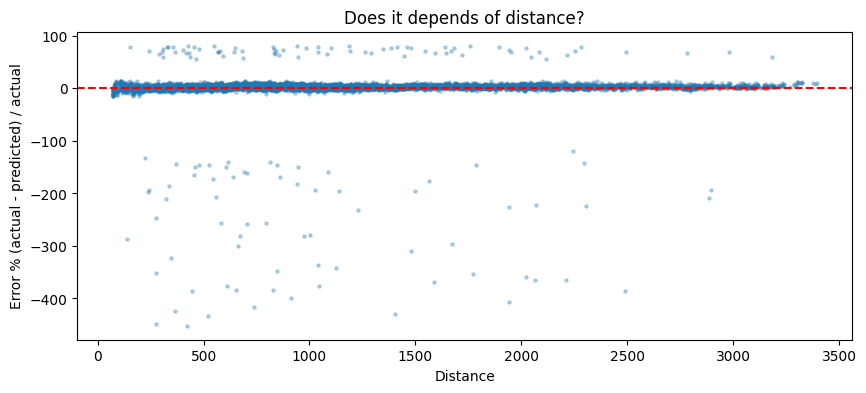

In [ ]:
plt.figure(figsize=(10,4))
plt.scatter(diag_df['distance'], diag_df['residual_pct'], s=5, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Distance')
plt.ylabel('Error % (actual - predicted) / actual')
plt.title('Does it depends of distance?')
plt.show()

### 7.2 Large-error cases — characteristics

In [ ]:
big_neg = diag_df[diag_df['residual_pct'] < -50]   
big_pos = diag_df[diag_df['residual_pct'] > 50]   

print('How many cases are there of each:')
print('Over:', len(big_neg), ' Under:', len(big_pos), ' Total test:', len(diag_df))
print()
print('Characteristics of the cases with LARGE overestimation:')
print(big_neg[['distance','weight','market_index','quote_signal']].describe())
print()
print('Characteristics of the entire test set (for comparison):')
print(diag_df[['distance','weight','market_index','quote_signal']].describe())

How many cases are there of each:
Over: 71  Under: 73  Total test: 9523

Characteristics of the cases with LARGE overestimation:
          distance        weight  market_index  quote_signal
count    71.000000     71.000000     69.000000     71.000000
mean   1032.605634  29879.154930      0.925705      2.041797
std     697.418337   8212.089598      0.082277      0.284985
min     136.800000   7483.000000      0.750390      0.957010
25%     524.200000  24315.000000      0.866260      1.905575
50%     829.200000  28762.000000      0.920570      2.049900
75%    1488.100000  36228.000000      0.996570      2.257685
max    2897.400000  47304.000000      1.074070      2.558600

Characteristics of the entire test set (for comparison):
          distance        weight  market_index  quote_signal
count  9523.000000   9458.000000   9450.000000   9523.000000
mean   1135.242613  31559.249101      0.925857      2.068802
std     736.701237   8051.759565      0.082198      0.303075
min      70.000000  

In [ ]:
print('Equipment in cases with LARGE overestimation:')
print(big_neg['equipment'].value_counts(normalize=True))
print()
print('Equipment in the entire test set:')
print(diag_df['equipment'].value_counts(normalize=True))
print()
print('Most common origin cities in the overestimation cases:')
print(big_neg['pickup'].value_counts().head(10))
print()
print('Most common destination cities in the overestimation cases:')
print(big_neg['delivery'].value_counts().head(10))

Equipment in cases with LARGE overestimation:
equipment
Dry Van    0.507042
Reefer     0.267606
Flatbed    0.225352
Name: proportion, dtype: float64

Equipment in the entire test set:
equipment
Dry Van    0.562848
Reefer     0.251286
Flatbed    0.185866
Name: proportion, dtype: float64

Most common origin cities in the overestimation cases:
pickup
New York        6
Bakersfield     4
Philadelphia    3
Shreveport      3
Columbia        3
Memphis         3
Atlanta         3
Hartford        3
Raleigh         3
Nashville       3
Name: count, dtype: int64

Most common destination cities in the overestimation cases:
delivery
Fort Wayne      4
Greensboro      4
Milwaukee       3
Memphis         3
Tucson          3
Richmond        3
Baton Rouge     3
Houston         3
Jacksonville    2
Cincinnati      2
Name: count, dtype: int64


In [ ]:
print('New York like pickup — in the overestimation cases:', (big_neg['pickup']=='New York').mean())
print('New York like pickup — in the entire test set:', (diag_df['pickup']=='New York').mean())
print()
print('Bakersfield like pickup — in the overestimation cases:', (big_neg['pickup']=='Bakersfield').mean())
print('Bakersfield like pickup — in the entire test set:', (diag_df['pickup']=='Bakersfield').mean())

New York como pickup — en la sobreestimación: 0.08450704225352113
New York como pickup — en TODO el set: 0.017536490601701146

Bakersfield como pickup — en la sobreestimación: 0.056338028169014086
Bakersfield como pickup — en TODO el set: 0.025727186810878926


New York y Bakersfield aparecen algo sobrerrepresentados, pero son conteos muy chicos (6 y 4 filas) para tratarlos como una señal accionable — se confirma más abajo que no correlaciona con nada.

### 7.3 Does it depends on equipment?

In [ ]:
diag_df.groupby('equipment')['residual_pct'].agg(['mean', 'std'])

,mean,std
equipment,,
Dry Van,1.131214,23.863808
Flatbed,1.577755,25.675356
Reefer,1.463410,27.788045


The means are small and similar across equipment types (no systematic bias). Reefer has a bit more spread (std) — which makes sense, since refrigerated freight tends to have more volatile prices.


### 7.4 The real finding: what are these 144 cases?

We split the cases by error direction and measure the `predicted / actual` ratio instead of just the percent error.

In [ ]:
big = diag_df[diag_df['residual_pct'].abs() > 50].copy()
big['posted_rate'] = np.exp(y_test.loc[big.index])
big['ratio'] = big['pred'] / big['posted_rate']

over = big[big['ratio'] >= 1]   
under = big[big['ratio'] < 1]   

print(f'n = {len(big)}  (over={len(over)}, under={len(under)})')
print()
print('ratio pred/actual, overestimation:')
print(over['ratio'].describe()[['mean','min','max','std']])
print()
print('ratio pred/actual, underestimation (invertido 1/ratio para comparar directo):')
print((1/under['ratio']).describe()[['mean','min','max','std']])

n = 144  (over=71, under=73)

ratio pred/actual, overestimation:
mean    3.609424
min     2.199494
max     5.518477
std     1.003351
Name: ratio, dtype: float64

ratio pred/actual, underestimation (invertido 1/ratio para comparar directo):
mean    3.637428
min     2.223095
max     5.289162
std     0.851416
Name: ratio, dtype: float64


The two groups are almost a mirror image: the ratio goes from ~2.2x to ~5.6x in both directions (sometimes the real `posted_rate` is 2-5.6x LOWER than what the model predicts as reasonable, other times it's 2-5.6x HIGHER) — not a clean multiple (not exactly 2x, 5x, or 10x, so it's not a shifted-decimal error).

In [ ]:
big['distortion'] = np.where(big['ratio']>=1, big['ratio'], 1/big['ratio'])
print('correlations of distortion with each feature:')
for c in ['distance', 'weight', 'market_index', 'quote_signal']:
    corr = big[[c,'distortion']].dropna().corr().iloc[0,1]
    print(f'  {c:15s} corr = {corr: .4f}')

correlations of distortion with each feature:
  distance        corr = -0.0384
  weight          corr = -0.0778
  market_index    corr =  0.0922
  quote_signal    corr = -0.0340


No correlation goes above 0.1 — nothing we have (distance, weight, market_index, quote_signal, and we already saw equipment/city don't either) explains these 144 cases. The most reasonable read: this is multiplicative noise injected into `posted_rate` for ~1.5% of the rows, symmetric and not correlated with any input variable — the model keeps predicting the "sane" rate based on distance/equipment/weight, which is the correct thing to do.

### 7.5 Confirmation on the full 48,000 rows (not just the holdout)

The use 5-fold cross-validation so every row gets a prediction from a model that never saw it during training — this way we can measure the same pattern across the WHOLE dataset, not just September-October, without overfitting bias.

In [ ]:
from sklearn.model_selection import KFold, cross_val_predict

X_full = df_encoded[features_hgb]
y_full = df_encoded['log_rate']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_model = HistGradientBoostingRegressor(
    max_depth=8, learning_rate=0.03, max_iter=400, l2_regularization=0.1, random_state=42
)
oof_pred_log = cross_val_predict(cv_model, X_full, y_full, cv=kf, n_jobs=-1)

full = df_encoded.copy()
full['pred'] = np.exp(oof_pred_log)
full['posted_rate'] = df['posted_rate'].values
full['residual_pct'] = (full['posted_rate'] - full['pred']) / full['posted_rate'] * 100
full['ratio'] = full['pred'] / full['posted_rate']

big_full = full[full['residual_pct'].abs() > 50]
print(f'Total rows: {len(full):,}   |residual_pct|>50: {len(big_full)}  ({len(big_full)/len(full)*100:.2f}%)')

over_full = big_full[big_full['ratio'] >= 1]
under_full = big_full[big_full['ratio'] < 1]
print(f'Overestimation: {len(over_full)}   Underestimation: {len(under_full)}')

Total rows: 48,000   |residual_pct|>50: 677  (1.41%)
Overestimation: 337   Underestimation: 340


In [ ]:
print('ratio pred/actual, Overestimation (dataset):')
print(over_full['ratio'].describe()[['mean','min','max','std']])
print()
print('ratio pred/actual, Underestimation, inverted (dataset ):')
print((1/under_full['ratio']).describe()[['mean','min','max','std']])
print()
big_full = big_full.copy()
big_full['distortion'] = np.where(big_full['ratio']>=1, big_full['ratio'], 1/big_full['ratio'])
print('Correlations of distortion with each feature (dataset completo):')
for c in ['distance', 'weight', 'market_index', 'quote_signal']:
    corr = big_full[[c,'distortion']].dropna().corr().iloc[0,1]
    print(f'  {c:15s} corr = {corr: .4f}')
print()
print('Distribution by month (compare with ~9-10.5% natural by month):')
print((full.loc[big_full.index, 'date'].dt.month.value_counts(normalize=True).sort_index() * 100).round(2))

ratio pred/actual, Overestimation (dataset):
mean    3.719427
min     2.259308
max     6.127078
std     0.977902
Name: ratio, dtype: float64

ratio pred/actual, Underestimation, inverted (dataset ):
mean    3.523348
min     2.173773
max     5.228041
std     0.801952
Name: ratio, dtype: float64

Correlations of distortion with each feature (dataset completo):
  distance        corr =  0.0025
  weight          corr = -0.0572
  market_index    corr =  0.1064
  quote_signal    corr = -0.0524

Distribution by month (compare with ~9-10.5% natural by month):
date
1     11.96
2      8.42
3     10.49
4      9.75
5      9.16
6      9.31
7      9.60
8     10.04
9      9.45
10    11.82
Name: proportion, dtype: float64


**Confirmed on the full 48,000 rows:** ~1.4% of the whole dataset (not just the holdout), almost the same 50/50 split between over- and underestimation, the same distortion range (2-6x), no correlation with any feature, and spread evenly across the 10 months — it doesn't concentrate in any one period. This makes the conclusion solid: it's not a business pattern the model missed, it's noise in the label (`posted_rate`) for a small, even fraction of the rows.

## 8. Conclusions
Final model: HistGradientBoostingRegressor, with date as a normal feature (not forced), hyperparameters tuned on this same feature set — **honest MAPE ~5.59%** vs. 6.03% for the baseline (5.69% with date but no tuning; 5.98% with no date at all).
Adding date in a moderate way (`doy_sin`/`doy_cos`/`days_since_start` as normal features) gains more than forcing an explicit seasonal correction, or than tuning hyperparameters — the tree's own regularization discipline is what makes the difference.
Weight had a sign bug (fixed with `abs()`), and `market_index`/`weight` have missing values handled natively by the model.
~1.4-1.5% of the rows (holdout and full dataset) have multiplicative noise injected into `posted_rate`, symmetric and unrelated to any available variable — this is not something the model should, or can, fix.